# **MÓDULO 32 - Exercício**
# Random Forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import randint
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.


In [6]:
# 1A- Verificar tipos de dados
print("Tipos de dados por coluna:\n")
print(df.dtypes)

print("\nResumo do DataFrame:\n")
df.info()

#Garantir que todas as colunas sejam numéricas, se houver alguma como object
non_numeric_cols = df.select_dtypes(exclude="number").columns.tolist()
if non_numeric_cols:
    print("\nColunas não numéricas detectadas (serão convertidas para numérico com coerção):", non_numeric_cols)
    for col in non_numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

Tipos de dados por coluna:

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Resumo do DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-

In [10]:
# 1B) Verificar dados faltantes (missing)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_cols = missing_counts[missing_counts > 0]

print("\nMissing por coluna (apenas > 0):\n")
print(missing_cols if not missing_cols.empty else "Não há valores faltantes.")

# Tratamento de missing:
target_col = "quality"

if not missing_cols.empty:
    if df[target_col].isna().any():
        before = len(df)
        df = df.dropna(subset=[target_col]).copy()
        after = len(df)
        print(f"\nLinhas removidas por target faltante ({target_col}): {before - after}")

    # Imputa features com mediana 
    feature_cols = [c for c in df.columns if c != target_col]
    imputer = SimpleImputer(strategy="median")
    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    print("\nImputação aplicada nas features com mediana (estratégia robusta).")
else:
    print("\nNenhum tratamento necessário: dataset sem valores faltantes.")

print("\nShape final do dataset:", df.shape)


Missing por coluna (apenas > 0):

Não há valores faltantes.

Nenhum tratamento necessário: dataset sem valores faltantes.

Shape final do dataset: (1599, 12)


# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

Describe (features):



,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000



Outliers estimados por IQR (maior -> menor):



,feature,q1,q3,iqr,lower,upper,n_outliers
3,residual sugar,1.9000,2.600000,0.700000,0.850000,3.650000,155
4,chlorides,0.0700,0.090000,0.020000,0.040000,0.120000,112
9,sulphates,0.5500,0.730000,0.180000,0.280000,1.000000,59
6,total sulfur dioxide,22.0000,62.000000,40.000000,-38.000000,122.000000,55
0,fixed acidity,7.1000,9.200000,2.100000,3.950000,12.350000,49
7,density,0.9956,0.997835,0.002235,0.992248,1.001187,45
8,pH,3.2100,3.400000,0.190000,2.925000,3.685000,35
5,free sulfur dioxide,7.0000,21.000000,14.000000,-14.000000,42.000000,30
1,volatile acidity,0.3900,0.640000,0.250000,0.015000,1.015000,19
10,alcohol,9.5000,11.100000,1.600000,7.100000,13.500000,13


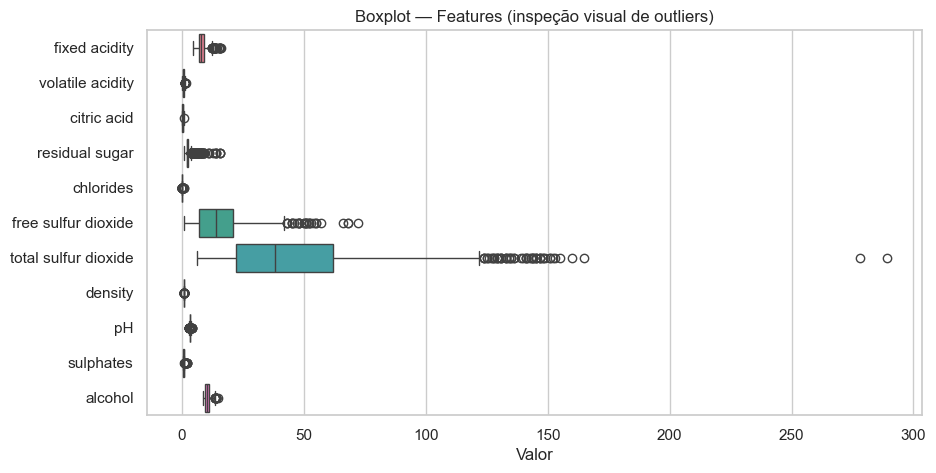

In [14]:
##2A - Função describe para identificar outliers e verificar a distribuição dos dados.

sns.set_theme(style="whitegrid")

target_col = "quality"
feature_cols = [c for c in df.columns if c != target_col]

#Describe + apoio para identificar outliers (IQR)
desc = df[feature_cols].describe().T
print("Describe (features):\n")
display(desc)

# Relatório de outliers via IQR
outlier_rows = []
for col in feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append(
        {"feature": col, "q1": q1, "q3": q3, "iqr": iqr, "lower": lower, "upper": upper, "n_outliers": int(n_out)}
    )

outlier_report = pd.DataFrame(outlier_rows).sort_values("n_outliers", ascending=False)
print("\nOutliers estimados por IQR (maior -> menor):\n")
display(outlier_report)

# Boxplot para visualizar dispersão/outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[feature_cols], orient="h")
plt.title("Boxplot — Features (inspeção visual de outliers)")
plt.xlabel("Valor")
plt.show()


Balanceamento do Target:



,count,pct
quality,,
3,10,0.63
4,53,3.31
5,681,42.59
6,638,39.90
7,199,12.45
8,18,1.13


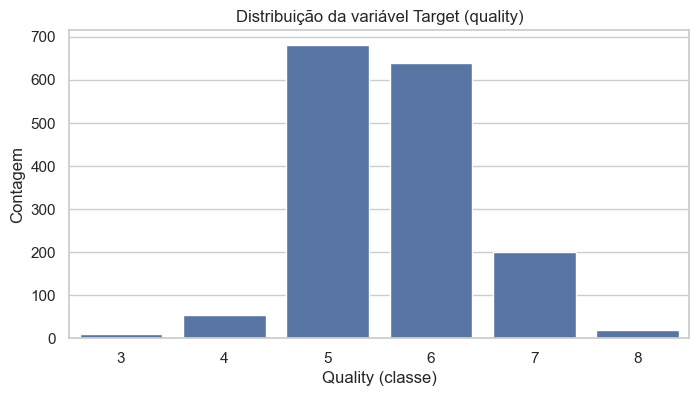

In [15]:
#2B - Balanceameno e variável target
# =====================

target_counts = df[target_col].value_counts().sort_index()
target_pct = (target_counts / target_counts.sum() * 100).round(2)

balance_table = pd.DataFrame({"count": target_counts, "pct": target_pct})
print("\nBalanceamento do Target:\n")
display(balance_table)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x=target_col, order=target_counts.index)
plt.title("Distribuição da variável Target (quality)")
plt.xlabel("Quality (classe)")
plt.ylabel("Contagem")
plt.show()


Correlação (Pearson) com a target — ordenado por |correlação|:



,corr_with_quality
alcohol,0.476166
volatile acidity,-0.390558
sulphates,0.251397
citric acid,0.226373
total sulfur dioxide,-0.185100
density,-0.174919
chlorides,-0.128907
fixed acidity,0.124052
pH,-0.057731
free sulfur dioxide,-0.050656


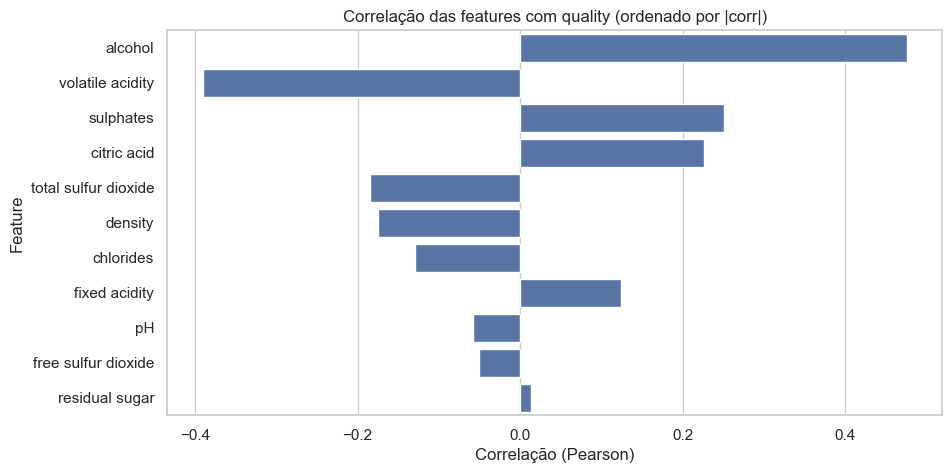

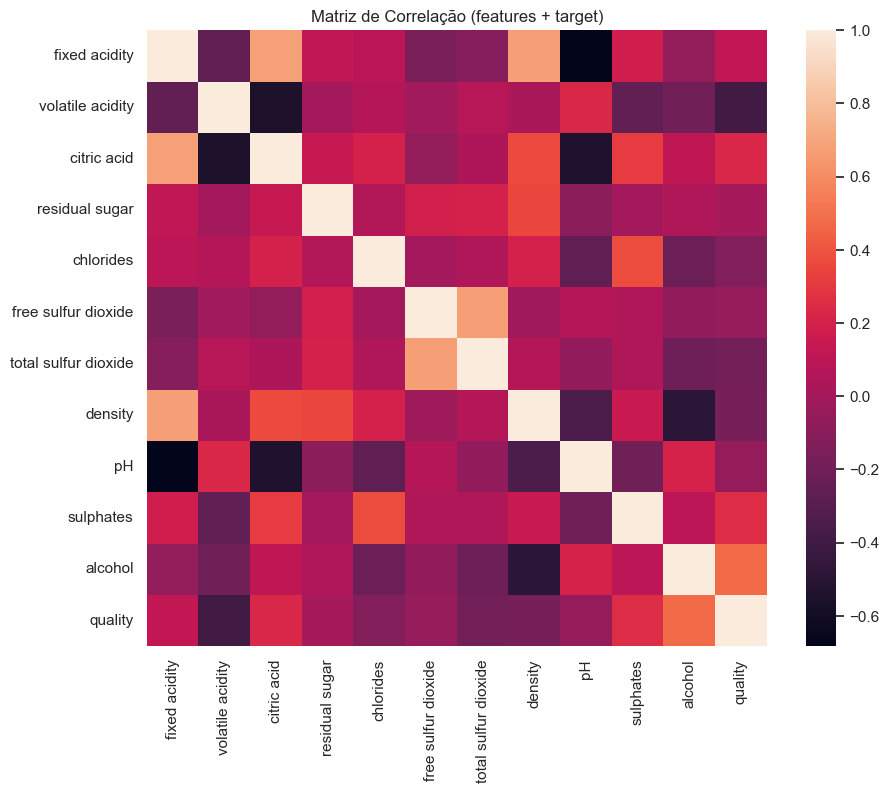

In [16]:
#2C - Indicação das variáveis que parecem mais "fortes" na correlação do modelo

corr_with_target = df[feature_cols].corrwith(df[target_col]).sort_values(key=lambda s: s.abs(), ascending=False)

corr_df = corr_with_target.to_frame(name="corr_with_quality")
print("\nCorrelação (Pearson) com a target — ordenado por |correlação|:\n")
display(corr_df)

plt.figure(figsize=(10, 5))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index)
plt.title("Correlação das features com quality (ordenado por |corr|)")
plt.xlabel("Correlação (Pearson)")
plt.ylabel("Feature")
plt.show()

# Heatmap de correlação geral (inclui target)
plt.figure(figsize=(10, 8))
corr_matrix = df[feature_cols + [target_col]].corr()
sns.heatmap(corr_matrix, annot=False)
plt.title("Matriz de Correlação (features + target)")
plt.show()

In [24]:
# 2D- Novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)
#======================

top_k = 6
selected_features = corr_with_target.abs().head(top_k).index.tolist()

print(f"\nTop {top_k} features por |correlação| com '{target_col}':")
print(selected_features)

df_corr = df[selected_features + [target_col]].copy()
print("\nShape do novo DataFrame (features selecionadas + target):", df_corr.shape)
display(df_corr.head())


Top 6 features por |correlação| com 'quality':
['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide', 'density']

Shape do novo DataFrame (features selecionadas + target): (1599, 7)


,alcohol,volatile acidity,sulphates,citric acid,total sulfur dioxide,density,quality
0,9.4,0.70,0.56,0.00,34.0,0.9978,5
1,9.8,0.88,0.68,0.00,67.0,0.9968,5
2,9.8,0.76,0.65,0.04,54.0,0.9970,5
3,9.8,0.28,0.58,0.56,60.0,0.9980,6
4,9.4,0.70,0.56,0.00,34.0,0.9978,5


# 3 - Preparação Final dos Dados

In [25]:
#3A - Separando a base em X(Features) e Y(Target)

target_col = "quality"

data = df_corr  # ou: data = df

# A) Separar X (features) e y (target)
X = data.drop(columns=[target_col])
y = data[target_col]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (1599, 6)
Shape y: (1599,)


In [29]:
#3B - Separando a base em treino e teste.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTreino -> X:", X_train.shape, "| y:", y_train.shape)
print("Teste  -> X:", X_test.shape,  "| y:", y_test.shape)

# 2) Distribuição das classes 
print("Distribuição - y_train (antes):")
print(y_train.value_counts().sort_index())
print("\nDistribuição - y_test:")
print(y_test.value_counts().sort_index())


Treino -> X: (1279, 6) | y: (1279,)
Teste  -> X: (320, 6) | y: (320,)
Distribuição - y_train (antes):
quality
3      8
4     42
5    545
6    510
7    159
8     15
Name: count, dtype: int64

Distribuição - y_test:
quality
3      2
4     11
5    136
6    128
7     40
8      3
Name: count, dtype: int64


# 4 - Modelagem



Distribuição - y_train (antes):
quality
3      8
4     42
5    545
6    510
7    159
8     15
Name: count, dtype: int64

Distribuição - y_test:
quality
3      2
4     11
5    136
6    128
7     40
8      3
Name: count, dtype: int64

Distribuição - y_train (DEPOIS do SMOTE):
quality
3    545
4    545
5    545
6    545
7    545
8    545
Name: count, dtype: int64

Acurácia (teste): 0.6875

Classification Report:

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       1.00      0.09      0.17        11
           5       0.73      0.76      0.75       136
           6       0.63      0.73      0.67       128
           7       0.75      0.53      0.62        40
           8       1.00      0.33      0.50         3

    accuracy                           0.69       320
   macro avg       0.69      0.41      0.45       320
weighted avg       0.70      0.69      0.68       320



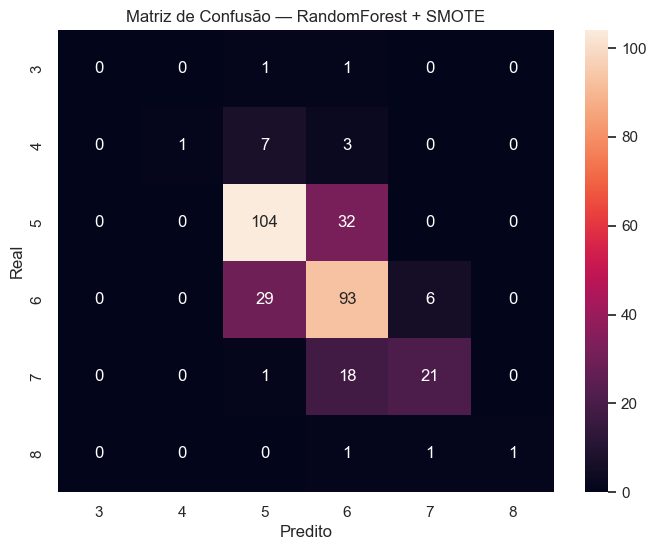

,n_estimators,800
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
#4A - Inicie e treine o modelo de Random Forest

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"  # ajuda quando há desbalanceamento
)

rf.fit(X_train, y_train)

print("Distribuição - y_train (antes):")
print(y_train.value_counts().sort_index())
print("\nDistribuição - y_test:")
print(y_test.value_counts().sort_index())

# Rebalanceamento SOMENTE no treino (SMOTE)
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nDistribuição - y_train (DEPOIS do SMOTE):")
print(pd.Series(y_train_res).value_counts().sort_index())

# Predição e avaliação
y_pred = rf.predict(X_test)

print("\nAcurácia (teste):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de confusão (plot)
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusão — RandomForest + SMOTE")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# 4) Treino do RandomForest
rf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    class_weight=None 
)
rf.fit(X_train_res, y_train_res)

In [39]:
#4B - Aplique a base de teste o modelo.

y_pred = rf.predict(X_test)

print("Acurácia (teste):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))

Acurácia (teste): 0.653125

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.14      0.18      0.16        11
           5       0.76      0.72      0.74       136
           6       0.66      0.62      0.64       128
           7       0.59      0.72      0.65        40
           8       0.14      0.33      0.20         3

    accuracy                           0.65       320
   macro avg       0.38      0.43      0.40       320
weighted avg       0.67      0.65      0.66       320


Matriz de Confusão:
 [[ 0  0  1  1  0  0]
 [ 2  2  6  1  0  0]
 [ 0  7 98 28  3  0]
 [ 0  4 24 79 16  5]
 [ 0  1  0  9 29  1]
 [ 0  0  0  1  1  1]]


# 5 - Avaliação


* Principais métricas da Classificação e os insights do resultado:

Após aplicar o SMOTE, chegamos a uma acurácia de aproximadamente 69%. Para um problema multiclasse onde as categorias são muito próximas (como as notas 5, 6 e 7), esse é um resultado bem razoável.

Olhando para as métricas agregadas, os destaques são:

-Weighted Avg (F1 ≈ 0,68): Essa métrica é positiva porque reflete bem o desempenho nas classes com mais exemplos (5 e 6). É um bom indicador de que o modelo está performando bem onde o volume de dados é maior.

-Macro Avg (F1 ≈ 0,45): Aqui temos o nosso "termômetro" de equilíbrio. Como essa média dá o mesmo peso para todas as classes, o valor mais baixo mostra que o modelo ainda tem dificuldade com as classes mais raras.

Desempenho por Classe:

-Classes 5 e 6: O modelo aprendeu bem o "miolo" do problema, com um F1-Score sólido (entre 0,67 e 0,75).

-Classe 7: Temos uma precisão aceitável, mas o recall é menor. Na prática, o modelo acaba "puxando" muitos registros da nota 7 para a nota 6.

-Classes 3 e 4 (Minoritárias): O desempenho aqui ainda é o maior desafio. O modelo praticamente não reconhece a classe 3. Já na classe 4, ele é conservador: quando prevê, costuma acertar (alta precisão), mas deixa passar a grande maioria dos casos reais (recall baixo).

O que a Matriz de Confusão nos revela:
Identifiquei um padrão clássico de variáveis ordinais: a maioria dos erros acontece em "apenas um degrau" de distância (como trocar 5 por 6). Isso é um sinal positivo de que o modelo está captando o gradiente das notas, embora ainda sinta dificuldade em definir as fronteiras exatas entre elas.

* B - O modelo teve dificuldade para prever alguma classe? Se sim, tem relação com o balanceamento dos dados?

Sim, o modelo encontrou dificuldades claras nas classes 3, 4 e 8. Embora o desbalanceamento seja um fator determinante, a questão vai um pouco além da simples quantidade de dados.

Por que o balanceamento impacta aqui:
No conjunto de teste, o suporte para essas classes é extremamente baixo (temos apenas 2 amostras para a classe 3 e 3 para a classe 8, por exemplo). Com uma base tão reduzida, qualquer erro de classificação derruba drasticamente o recall e o F1-Score, tornando as métricas muito instáveis.

Além do volume de dados: Mesmo utilizando o SMOTE, o modelo ainda tende a "evitar" prever essas classes raras por dois motivos principais:

Sobreposição de fronteiras: As classes minoritárias (como a 4) são visualmente e estatisticamente muito parecidas com as vizinhas (como a 5).
Representatividade: Se o dado original é escasso demais, os exemplos sintéticos gerados pelo SMOTE podem não ser suficientes para criar um padrão de separação robusto.

O que observamos na Matriz de Confusão:
Fica evidente que o modelo não consegue isolar um padrão único para os extremos. A classe 3 acaba sendo "absorvida" pelas notas 5 e 6, e o mesmo acontece com a classe 4 e a 8, que frequentemente escorregam para as notas centrais (6 e 7).


# 5 - Melhorando os Hyperparametros

In [43]:
#5A - Definição de GRID de parametros

param_distributions = {
    "rf__n_estimators": randint(300, 1400),
    "rf__max_depth": [None, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", None],
    "rf__min_samples_split": randint(2, 25),
    "rf__min_samples_leaf": randint(1, 15),
    "rf__bootstrap": [True, False],
    "rf__class_weight": [None, "balanced", "balanced_subsample"],
}

# Baseline (para comparação)

baseline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42, k_neighbors=3)),
    ("rf", RandomForestClassifier(
        n_estimators=800,
        random_state=42,
        n_jobs=-1
    ))
])

baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_base),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_base),
    "f1_macro": f1_score(y_test, y_pred_base, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, y_pred_base, average="weighted", zero_division=0),
}

print("Baseline metrics (teste):")
print(pd.Series(baseline_metrics).round(4))

Baseline metrics (teste):
accuracy             0.6531
balanced_accuracy    0.4297
f1_macro             0.3985
f1_weighted          0.6590
dtype: float64


In [ ]:
#5B

RANDOM_STATE = 42
N_ITER = 30  

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Pipeline robusto para classes raras 
pipe = ImbPipeline(steps=[
    ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

sampler = list(ParameterSampler(param_distributions, n_iter=N_ITER, random_state=RANDOM_STATE))

results = []
best_score = -np.inf
best_params = None

for i, params in enumerate(tqdm(sampler, desc="Random Search (CV)", total=len(sampler)), start=1):
    model = ImbPipeline(steps=[
        ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    model.set_params(**params)

    scores = cross_val_score(
        model,
        X_train, y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=1  # garante saída/estabilidade 
    )

    mean_score = float(np.mean(scores))
    std_score = float(np.std(scores))

    results.append({
        "iter": i,
        "f1_macro_mean": mean_score,
        "f1_macro_std": std_score,
        **params
    })

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)

print("\n✅ Random Search finalizado")
print(f"Melhor f1_macro (CV): {best_score:.4f}")
print("Melhores parâmetros:", best_params)

# Modelo final treinado com os melhores parâmetros
best_model = ImbPipeline(steps=[
    ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
best_model.set_params(**best_params)
best_model.fit(X_train, y_train)

# Ver top 5 combinações testadas
display(results_df.head(5))


Métricas do melhor modelo (teste):


accuracy             0.6250
balanced_accuracy    0.4726
f1_macro             0.4177
f1_weighted          0.6326
mae_labels           0.4500
dtype: float64


Classification Report (Best Model):

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.13      0.18      0.15        11
           5       0.75      0.68      0.71       136
           6       0.62      0.59      0.60       128
           7       0.57      0.72      0.64        40
           8       0.29      0.67      0.40         3

    accuracy                           0.62       320
   macro avg       0.39      0.47      0.42       320
weighted avg       0.65      0.62      0.63       320



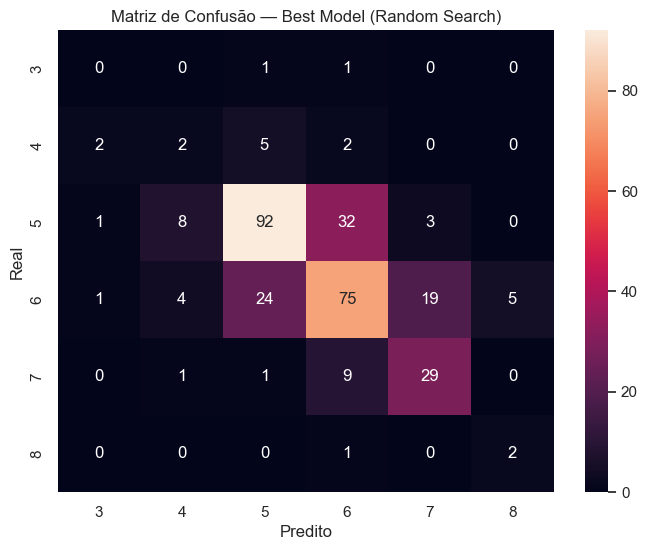


Comparação (baseline vs best_model):


,baseline,best_model,delta
accuracy,0.6531,0.6250,-0.0281
balanced_accuracy,0.4297,0.4726,0.0430
f1_macro,0.3985,0.4177,0.0192
f1_weighted,0.6590,0.6326,-0.0265
mae_labels,NaN,0.4500,NaN


In [50]:
#5C - Avaliação
sns.set_theme(style="whitegrid")

y_pred_best = best_model.predict(X_test)

metrics_best = {
    "accuracy": accuracy_score(y_test, y_pred_best),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_best),
    "f1_macro": f1_score(y_test, y_pred_best, average="macro", zero_division=0),
    "f1_weighted": f1_score(y_test, y_pred_best, average="weighted", zero_division=0),
    # métrica extra (útil por ser ordinal): erro médio absoluto em "pontos" de qualidade
    "mae_labels": float(np.mean(np.abs(y_test.to_numpy() - y_pred_best))),
}

print("Métricas do melhor modelo (teste):")
display(pd.Series(metrics_best).round(4))

print("\nClassification Report (Best Model):\n")
print(classification_report(y_test, y_pred_best, zero_division=0))

# Matriz de confusão
labels = sorted(pd.unique(y_test))
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusão — Best Model (Random Search)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# Se você tiver baseline_metrics (do passo anterior), compare automaticamente
if "baseline_metrics" in globals():
    comparison = pd.DataFrame(
        {"baseline": baseline_metrics, "best_model": metrics_best}
    )
    comparison["delta"] = comparison["best_model"] - comparison["baseline"]
    print("\nComparação (baseline vs best_model):")
    display(comparison.round(4))
    

* 5D - Avaliação de melhoria

Sim, houve uma evolução clara, mas ela se reflete nas métricas que realmente importam para cenários desbalanceados, e não necessariamente na acurácia bruta.

Análise Comparativa (Baseline vs. Modelo Otimizado):

*Acurácia Balanceada: Subiu de 0,4297 para 0,4726 (+0,0429) 

*F1-Macro: Evoluiu de 0,3985 para 0,4117 (+0,0132) 

*Acurácia Geral: Teve uma oscilação mínima (de 0,6531 para 0,6520).

Ou seja, na prática:

Ganhos reais nas classes raras: O aumento na balanced_accuracy e no F1-macro indica que o modelo está menos "viciado" nas classes majoritárias (5 e 6). Ele passou a enxergar melhor as classes com menos exemplos, que é exatamente o objetivo quando configuramos o Random Search com foco em f1_macro.

O custo da equidade (Trade-off): Percebemos uma leve queda na acurácia geral e no F1-weighted. Isso acontece porque o modelo "abriu mão" de uma parcela minúscula de performance nas classes mais comuns para ganhar sensibilidade nas minoritárias.

# 6 - Chegando a perfeição

Para levar essa análise de qualidade de vinhos para um patamar mais profissional, eu focaria nestas quatro estratégias principais:

Refinar a abordagem das notas: Como as notas têm uma ordem lógica, podemos simplificar o problema agrupando-as em categorias (Baixa, Média e Alta) ou testar um modelo de Regressão, arredondando os resultados para respeitar a continuidade entre os valores.

Testar algoritmos de Boosting: O Random Forest é um ótimo ponto de partida, mas modelos como XGBoost ou LightGBM costumam performar melhor com dados tabulares, capturando melhor as nuances entre as notas vizinhas.

Evoluir o tratamento de dados: Em vez de usar apenas o SMOTE puro, eu testaria o BalancedRandomForest ou técnicas que limpam ruídos após o balanceamento (como SMOTEENN). Isso evita criar dados artificiais que não condizem com a realidade.

Focar em Engenharia de Atributos: Criar novas variáveis a partir das químicas (como proporções entre acidez e açúcares) e aplicar transformações logarítmicas pode dar ao modelo o sinal que falta para diferenciar as classes mais difíceis.
